In [1]:
#  CELL 1: Complete Setup & Manual Dataset Handler
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from google.colab.patches import cv2_imshow

# Google Drive mount
drive.mount('/content/drive')
# Project folder
project_path = '/content/drive/MyDrive/Gesture_Controller'
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)
print(" Project setup complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Project setup complete!


In [2]:
#cell 2
from google.colab import files
files.upload()


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"f223280saniaabid","key":"721d4bf001300fb6930930b5e9de5273"}'}

In [3]:
#cell 3
!mkdir -p ~/.kaggle

In [4]:
# cell 4
!cp kaggle.json ~/.kaggle/

In [5]:
#cell 5
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
#cell 6
!ls ~/.kaggle

kaggle.json


In [7]:
#cell 7
!kaggle datasets list -s hagrid


ref                                                       title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  -----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
innominate817/hagrid-sample-30k-384p                      HaGRID Sample 30k 384p                             863204959  2022-09-08 00:36:55.150000           1946         29  0.875            
kapitanov/hagrid                                          HaGRID - HAnd Gesture Recognition Image Dataset    353909534  2022-10-21 11:37:55.687000           5051        124  0.875            
innominate817/hagrid-classification-512p                  HaGRID Classification 512p                       12525314405  2022-10-02 22:16:01.377000            736         11  0.875            
innominate817/hagrid-sample-120k-384p   

In [8]:
#cell 8
!kaggle datasets download -d innominate817/hagrid-sample-30k-384p


Dataset URL: https://www.kaggle.com/datasets/innominate817/hagrid-sample-30k-384p
License(s): CC-BY-SA-4.0
hagrid-sample-30k-384p.zip: Skipping, found more recently modified local copy (use --force to force download)


In [9]:
#cell 9
!unzip -o hagrid-sample-30k-384p.zip -d hagrid30k


Streaming output truncated to the last 5000 lines.
  inflating: hagrid30k/hagrid-sample-30k-384p/hagrid_30k/train_val_three2/34266f02-173a-4b57-92a6-ec6b31133758.jpg  
  inflating: hagrid30k/hagrid-sample-30k-384p/hagrid_30k/train_val_three2/344022b9-8475-4649-bb2d-0b94701d8a49.jpg  
  inflating: hagrid30k/hagrid-sample-30k-384p/hagrid_30k/train_val_three2/3466c3f4-c9c9-4bfc-8dce-3631935ccf71.jpg  
  inflating: hagrid30k/hagrid-sample-30k-384p/hagrid_30k/train_val_three2/34878ee4-4c76-491b-96d4-554e01247a42.jpg  
  inflating: hagrid30k/hagrid-sample-30k-384p/hagrid_30k/train_val_three2/34bb9230-a0b5-4a6d-a3dd-1409043a7509.jpg  
  inflating: hagrid30k/hagrid-sample-30k-384p/hagrid_30k/train_val_three2/34d37ccb-7110-4ec5-9253-58e2d6b0a530.jpg  
  inflating: hagrid30k/hagrid-sample-30k-384p/hagrid_30k/train_val_three2/34fb8160-3a0d-47e9-82fb-342ce1367a6c.jpg  
  inflating: hagrid30k/hagrid-sample-30k-384p/hagrid_30k/train_val_three2/35177a5d-2e74-413a-9670-cfd1a570f9d7.jpg  
  inflating: 

In [10]:
#cell 10
!unzip -t hagrid-sample-30k-384p.zip


Streaming output truncated to the last 5000 lines.
    testing: hagrid-sample-30k-384p/hagrid_30k/train_val_three2/344022b9-8475-4649-bb2d-0b94701d8a49.jpg   OK
    testing: hagrid-sample-30k-384p/hagrid_30k/train_val_three2/3466c3f4-c9c9-4bfc-8dce-3631935ccf71.jpg   OK
    testing: hagrid-sample-30k-384p/hagrid_30k/train_val_three2/34878ee4-4c76-491b-96d4-554e01247a42.jpg   OK
    testing: hagrid-sample-30k-384p/hagrid_30k/train_val_three2/34bb9230-a0b5-4a6d-a3dd-1409043a7509.jpg   OK
    testing: hagrid-sample-30k-384p/hagrid_30k/train_val_three2/34d37ccb-7110-4ec5-9253-58e2d6b0a530.jpg   OK
    testing: hagrid-sample-30k-384p/hagrid_30k/train_val_three2/34fb8160-3a0d-47e9-82fb-342ce1367a6c.jpg   OK
    testing: hagrid-sample-30k-384p/hagrid_30k/train_val_three2/35177a5d-2e74-413a-9670-cfd1a570f9d7.jpg   OK
    testing: hagrid-sample-30k-384p/hagrid_30k/train_val_three2/354f5c8a-2d3f-4565-9708-f0cb559dea0e.jpg   OK
    testing: hagrid-sample-30k-384p/hagrid_30k/train_val_three2/3568d

In [11]:
#cell 11
import os

root_dir = "hagrid30k"

for root, dirs, files in os.walk(root_dir):
    level = root.replace(root_dir, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files[:5]:     # every folder shows 5 files
        print(f"{subindent}{f}")


hagrid30k/
    hagrid-sample-30k-384p/
        ann_train_val/
            ok.json
            peace_inverted.json
            three2.json
            peace.json
            call.json
        hagrid_30k/
            train_val_dislike/
                01790ad5-c82f-4bd7-b225-6a8633026ca2.jpg
                037d3289-8481-4946-8a45-deff72a4e156.jpg
                00c84257-800d-4032-9e64-e47eb97005f5.jpg
                03ce7f66-2aec-41d0-a02e-527470249c6f.jpg
                033a4812-3505-4f5f-999f-17f41b38eac1.jpg
            train_val_call/
                faa99601-f7ea-42fa-8437-628067e46406.jpg
                fc859eba-0258-47d4-8922-60d863a984f1.jpg
                fbfb7397-5407-4b2f-917a-4b2c015f8271.jpg
                fd6bd04a-cf29-4a6c-bb06-96d47aa7b82b.jpg
                fcfac74d-b36c-499b-9f90-edb381a4c1f3.jpg
            train_val_fist/
                0031a6a9-9d93-4e63-907b-7fabe08a9209.jpg
                0051add8-5f64-4e7c-9bb9-ad2a3345cdea.jpg
                0076df79-2

In [12]:
# CELL 12: Analyze Dataset Structure
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Dataset path set
dataset_base = "hagrid30k/hagrid-sample-30k-384p"
print(f"Dataset base path: {dataset_base}")

# Check if path exists
if not os.path.exists(dataset_base):
    print(" Dataset path not found! Check the path.")
else:
    print(" Dataset path found!")

Dataset base path: hagrid30k/hagrid-sample-30k-384p
 Dataset path found!


In [13]:
#  CELL 13: Find Our Required Gestures
def find_our_gestures():
    base_path = "hagrid30k/hagrid-sample-30k-384p/hagrid_30k"

    our_required_gestures = ['call', 'fist', 'like', 'ok', 'palm', 'rock', 'stop', 'two_up']
    available_gestures = []

    print(" Searching for our required gestures...")

    for gesture in our_required_gestures:
        gesture_folder = f"train_val_{gesture}"
        gesture_path = os.path.join(base_path, gesture_folder)

        if os.path.exists(gesture_path):
            images = [f for f in os.listdir(gesture_path) if f.endswith('.jpg')]
            available_gestures.append((gesture, len(images), gesture_path))
            print(f" {gesture}: {len(images)} images")
        else:
            print(f" {gesture}: Not found")

    return available_gestures

available_gestures = find_our_gestures()

 Searching for our required gestures...
 call: 1763 images
 fist: 1735 images
 like: 1732 images
 ok: 1750 images
 palm: 1770 images
 rock: 1736 images
 stop: 1748 images
 two_up: 1855 images



  Showing real image samples  


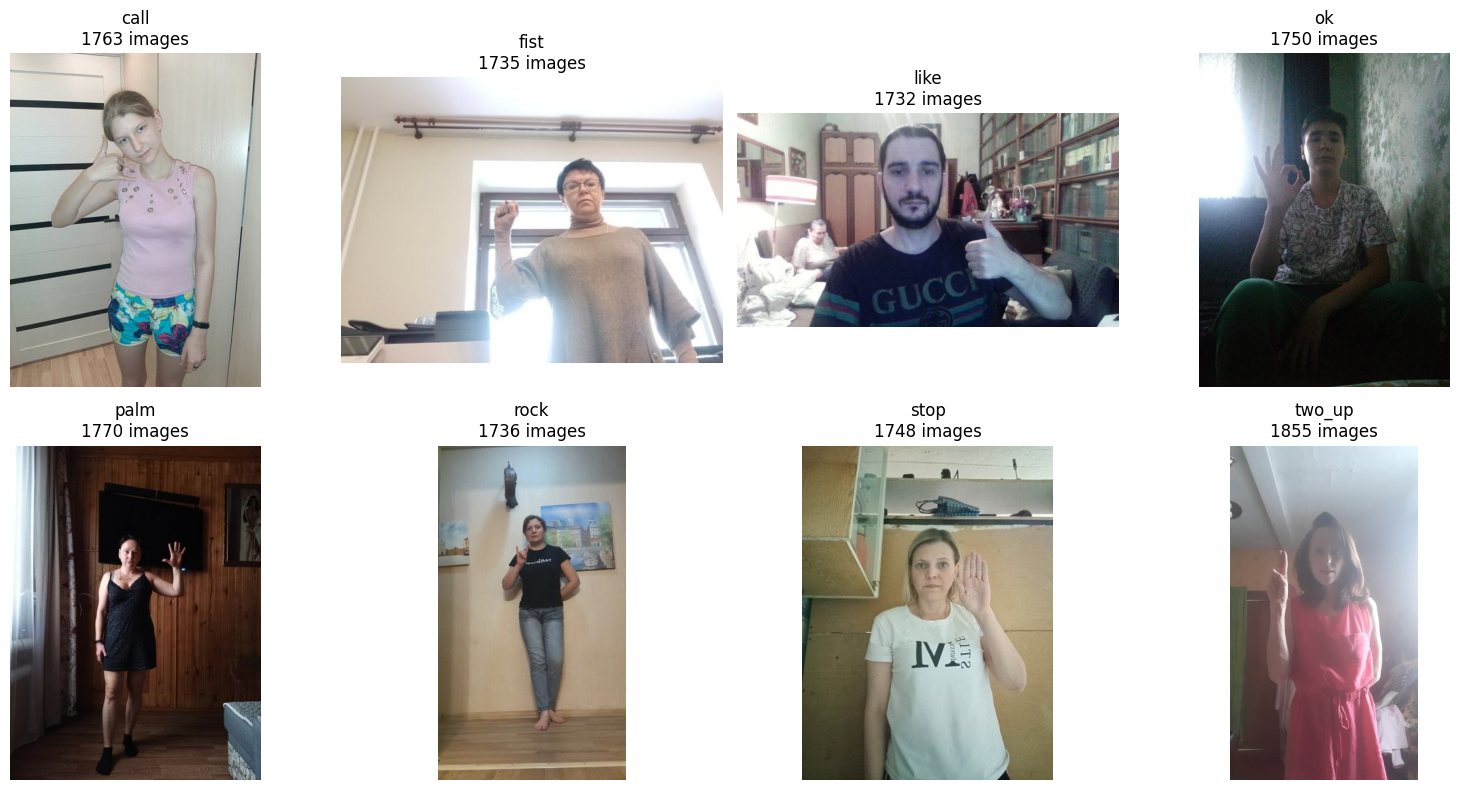

In [14]:
#  CELL 14: Show Real Image Samples
def show_real_samples(available_gestures, num_samples=8):
    print(f"\n  Showing real image samples  ")

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for idx, (gesture, count, path) in enumerate(available_gestures[:num_samples]):
        # Get first image from the folder
        images = [f for f in os.listdir(path) if f.endswith('.jpg')]
        if images:
            img_path = os.path.join(path, images[0])
            img = cv2.imread(img_path)

            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                row = idx // 4
                col = idx % 4
                axes[row, col].imshow(img_rgb)
                axes[row, col].set_title(f'{gesture}\n{count} images')
                axes[row, col].axis('off')
            else:
                axes[row, col].text(0.5, 0.5, f'{gesture}\nLoad Error',
                                  ha='center', va='center', fontsize=12)
                axes[row, col].axis('off')
        else:
            axes[row, col].text(0.5, 0.5, f'{gesture}\nNo Images',
                              ha='center', va='center', fontsize=12)
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

show_real_samples(available_gestures)

In [18]:
# ============================================
# MODULE 3: ADVANCED DEEP LEARNING & REAL-TIME GESTURE CONTROL
# Robust / fixed version
# ============================================

import os
import sys
import json
import time
import random
import datetime
import subprocess
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep Learning Imports
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, models, applications, optimizers, callbacks, regularizers
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    from tensorflow.keras.utils import to_categorical, plot_model
    # Common backbone imports
    from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
except Exception as e:
    print("Error importing TensorFlow or Keras:", e)
    raise

# Robust TF version check (avoid brittle string comparisons)
try:
    tf_ver_nums = tuple(int(x) for x in tf.__version__.split('.')[:2])
except Exception:
    tf_ver_nums = (0, 0)

# Preprocessing layers import (TF 2.6+ moved these)
try:
    if tf_ver_nums >= (2, 6):
        from tensorflow.keras.layers import RandomRotation, RandomZoom, RandomFlip
    else:
        # older TF
        from tensorflow.keras.layers.experimental.preprocessing import RandomRotation, RandomZoom, RandomFlip
except Exception as e:
    # if the specific import fails, define small fallback wrappers (no-op)
    print("Could not import preprocessing layers exactly as expected:", e)
    # define simple no-op placeholders so code that references them won't break
    class RandomRotation(tf.keras.layers.Layer):
        def __init__(self, *args, **kwargs): super().__init__()
    class RandomZoom(tf.keras.layers.Layer):
        def __init__(self, *args, **kwargs): super().__init__()
    class RandomFlip(tf.keras.layers.Layer):
        def __init__(self, *args, **kwargs): super().__init__()

# Computer Vision
try:
    import cv2
except Exception as e:
    print("OpenCV (cv2) import failed:", e)
    raise

# mediapipe is optional; attempt import and report if missing
try:
    import mediapipe as mp
except Exception as e:
    print("mediapipe not available (optional). To install: pip install mediapipe")
    mp = None  # allow rest of script to run without mediapipe

# Visualization (plotly optional)
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import matplotlib.cm as cm
except Exception:
    px = go = make_subplots = None
    # matplotlib and seaborn are available; continue

# IPython widgets are optional (only useful in notebooks)
try:
    from IPython.display import display, HTML, clear_output
    import ipywidgets as widgets
except Exception:
    display = HTML = clear_output = None
    widgets = None

# Model Explainability: tf-explain (install if missing, using subprocess not notebook '!' magic)
try:
    import tf_explain
    from tf_explain.core.grad_cam import GradCAM
    from tf_explain.core.occlusion_sensitivity import OcclusionSensitivity
    from tf_explain.core.smoothgrad import SmoothGrad
except Exception:
    print("tf_explain not installed. Attempting to install via pip...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "tf-explain"])
        importlib.invalidate_caches()
        import tf_explain
        from tf_explain.core.grad_cam import GradCAM
        from tf_explain.core.occlusion_sensitivity import OcclusionSensitivity
        from tf_explain.core.smoothgrad import SmoothGrad
        print("tf-explain installed successfully.")
    except Exception as e:
        print("Failed to install or import tf-explain. Explainability utilities will be disabled.", e)
        tf_explain = None
        GradCAM = OcclusionSensitivity = SmoothGrad = None

# Model Evaluation (sklearn)
try:
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    from sklearn.model_selection import train_test_split
except Exception as e:
    print("scikit-learn import failed:", e)
    raise

# Summary prints
print("="*70)
print("MODULE 3: ADVANCED DEEP LEARNING & INTELLIGENT VISION")
print("="*70)
print(f"TensorFlow Version: {tf.__version__}")
print(f"OpenCV Version: {cv2.__version__}")
print(f"NumPy Version: {np.__version__}")
print("="*70)

# GPU Check (robust)
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f" GPU Available: {len(gpus)} devices")
        for gpu in gpus:
            print(f"  - {gpu}")
    else:
        print(" No GPU detected. Training will be slower.")
except Exception as e:
    print("Could not query GPUs:", e)

# Create Module 3 directories with a safe default path (works in Colab and local)
# If running in Colab and drive is mounted, use drive path; otherwise use a local ./module3 folder
colab_drive_path = "/content/drive/MyDrive/Gesture_Controller/module3_deep_learning"
local_path = os.path.join(os.getcwd(), "module3_deep_learning")

if os.path.exists("/content/drive"):
    # If running in Colab and drive is mounted, try to use it; fallback to local if not mounted
    chosen_base = colab_drive_path
    try:
        os.makedirs(chosen_base, exist_ok=True)
        test_write = os.path.join(chosen_base, "._test_write")
        with open(test_write, "w") as f:
            f.write("ok")
        os.remove(test_write)
    except Exception:
        print("Drive path not writable. Falling back to local path.")
        chosen_base = local_path
else:
    chosen_base = local_path

module3_path = chosen_base
os.makedirs(module3_path, exist_ok=True)
os.makedirs(os.path.join(module3_path, "models"), exist_ok=True)
os.makedirs(os.path.join(module3_path, "results"), exist_ok=True)
os.makedirs(os.path.join(module3_path, "visualizations"), exist_ok=True)
os.makedirs(os.path.join(module3_path, "demo"), exist_ok=True)

print(f"Module 3 directories created at: {module3_path}")

# Optional: quick sanity check function
def quick_environment_check():
    info = {
        "python_executable": sys.executable,
        "tensorflow": tf.__version__,
        "opencv": cv2.__version__,
        "numpy": np.__version__,
        "tf_explain": getattr(tf_explain, "__version__", "not-installed") if 'tf_explain' in globals() else "not-installed",
        "mediapipe": getattr(mp, "__version__", "not-installed") if mp is not None else "not-installed",
        "gpu_count": len(tf.config.list_physical_devices('GPU')) if hasattr(tf, "config") else 0,
        "module3_path": module3_path
    }
    return info

# Print environment check
env = quick_environment_check()
print("Quick environment summary:")
for k, v in env.items():
    print(f" - {k}: {v}")

# Now the rest of your module code can follow...


mediapipe not available (optional). To install: pip install mediapipe
tf_explain not installed. Attempting to install via pip...
tf-explain installed successfully.
MODULE 3: ADVANCED DEEP LEARNING & INTELLIGENT VISION
TensorFlow Version: 2.19.0
OpenCV Version: 4.12.0
NumPy Version: 2.0.2
 GPU Available: 1 devices
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Module 3 directories created at: /content/drive/MyDrive/Gesture_Controller/module3_deep_learning
Quick environment summary:
 - python_executable: /usr/bin/python3
 - tensorflow: 2.19.0
 - opencv: 4.12.0
 - numpy: 2.0.2
 - tf_explain: 0.3.1
 - mediapipe: not-installed
 - gpu_count: 1
 - module3_path: /content/drive/MyDrive/Gesture_Controller/module3_deep_learning


Initializing Deep Learning Data Pipeline...
Loading dataset with (224, 224) image size...


Loading gestures: 100%|██████████| 8/8 [01:44<00:00, 13.01s/it]


Dataset loaded: 4000 images, 8 classes

Dataset Split:
  Training:   2800 images
  Validation: 600 images
  Testing:    600 images
Visualizing Data Augmentation...


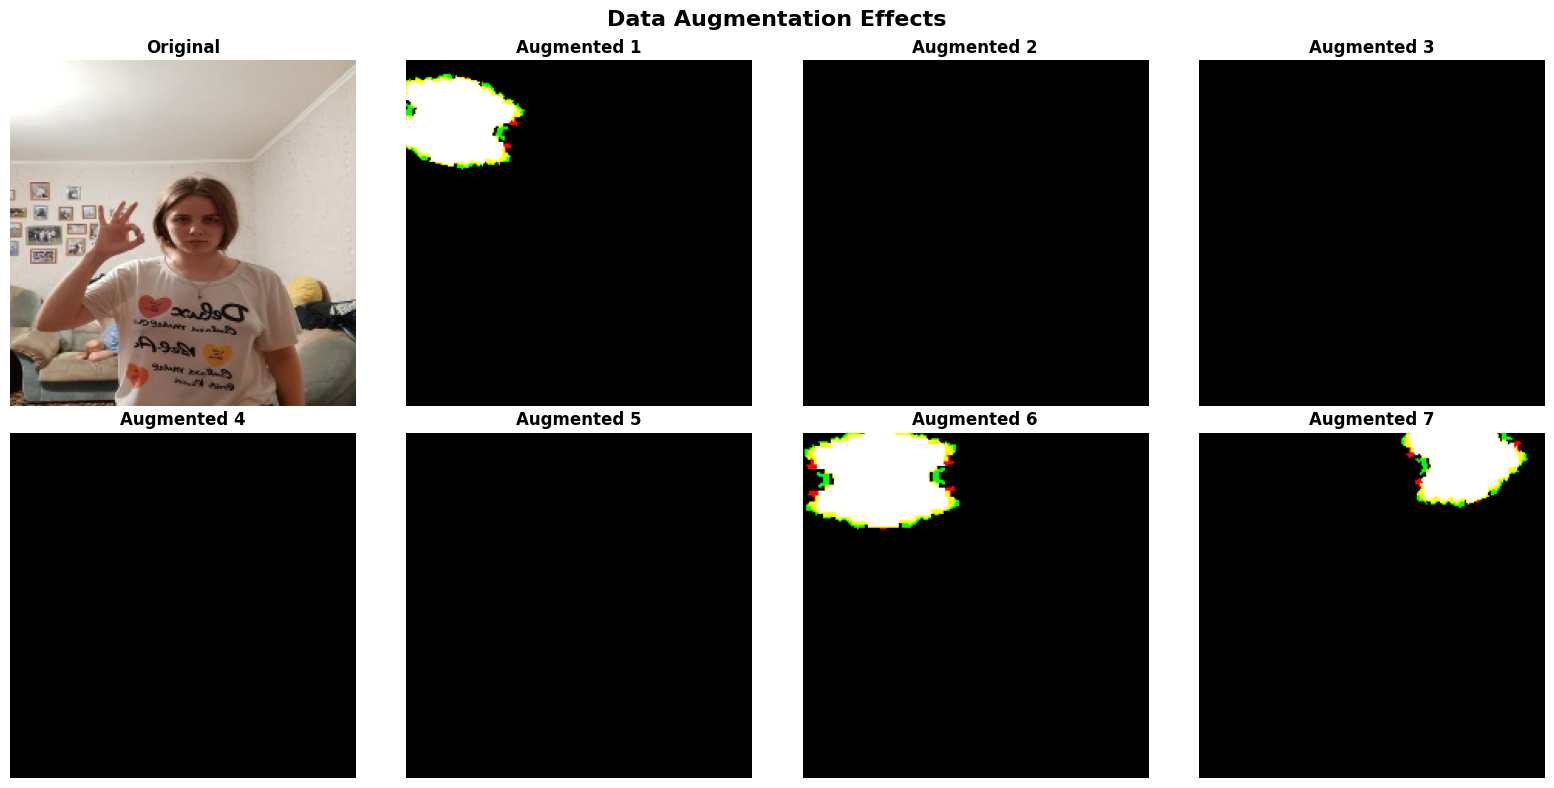

In [19]:
class DeepLearningDataPipeline:
    """Advanced data pipeline for deep learning with augmentation"""

    def __init__(self, dataset_path, gestures, img_size=(224, 224)):
        self.dataset_path = dataset_path
        self.gestures = gestures
        self.img_size = img_size
        self.num_classes = len(gestures)

    def load_dataset(self, max_samples_per_class=1000, test_split=0.2, val_split=0.1):
        """Load and split dataset for deep learning"""
        print(f"Loading dataset with {self.img_size} image size...")

        X = []  # Images
        y = []  # Labels
        gesture_labels = {gesture: idx for idx, gesture in enumerate(self.gestures)}

        for gesture in tqdm(self.gestures, desc="Loading gestures"):
            gesture_path = os.path.join(self.dataset_path, f"train_val_{gesture}")
            if not os.path.exists(gesture_path):
                print(f"Warning: {gesture_path} not found!")
                continue

            image_files = [f for f in os.listdir(gesture_path) if f.endswith('.jpg')]
            image_files = image_files[:max_samples_per_class]

            for img_file in tqdm(image_files, desc=f"  {gesture}", leave=False):
                img_path = os.path.join(gesture_path, img_file)
                img = cv2.imread(img_path)

                if img is not None:
                    # Resize and preprocess
                    img = cv2.resize(img, self.img_size)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = img.astype(np.float32) / 255.0

                    X.append(img)
                    y.append(gesture_labels[gesture])

        X = np.array(X)
        y = np.array(y)

        print(f"Dataset loaded: {X.shape[0]} images, {self.num_classes} classes")

        # Split dataset
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=test_split, random_state=42, stratify=y
        )

        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=val_split/(1-test_split), random_state=42, stratify=y_temp
        )

        print(f"\nDataset Split:")
        print(f"  Training:   {X_train.shape[0]} images")
        print(f"  Validation: {X_val.shape[0]} images")
        print(f"  Testing:    {X_test.shape[0]} images")

        # One-hot encode labels
        y_train_onehot = to_categorical(y_train, self.num_classes)
        y_val_onehot = to_categorical(y_val, self.num_classes)
        y_test_onehot = to_categorical(y_test, self.num_classes)

        return {
            'train': {'X': X_train, 'y': y_train, 'y_onehot': y_train_onehot},
            'val': {'X': X_val, 'y': y_val, 'y_onehot': y_val_onehot},
            'test': {'X': X_test, 'y': y_test, 'y_onehot': y_test_onehot}
        }

    def create_data_generators(self, data_dict, batch_size=32):
        """Create data generators with advanced augmentation"""

        # Advanced data augmentation for training
        train_datagen = ImageDataGenerator(
            rotation_range=30,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2],
            fill_mode='nearest',
            channel_shift_range=20.0
        )

        # Validation/Test datagen (only normalization)
        val_datagen = ImageDataGenerator()

        train_generator = train_datagen.flow(
            data_dict['train']['X'],
            data_dict['train']['y_onehot'],
            batch_size=batch_size,
            shuffle=True
        )

        val_generator = val_datagen.flow(
            data_dict['val']['X'],
            data_dict['val']['y_onehot'],
            batch_size=batch_size,
            shuffle=False
        )

        test_generator = val_datagen.flow(
            data_dict['test']['X'],
            data_dict['test']['y_onehot'],
            batch_size=batch_size,
            shuffle=False
        )

        return train_generator, val_generator, test_generator

    def visualize_augmentation(self, X_sample, n_samples=8):
        """Visualize data augmentation effects"""
        print("Visualizing Data Augmentation...")

        # Create augmentation pipeline
        aug_datagen = ImageDataGenerator(
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.3,
            shear_range=0.3,
            zoom_range=0.3,
            horizontal_flip=True,
            brightness_range=[0.7, 1.3],
            fill_mode='reflect'
        )

        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.ravel()

        # Original image
        axes[0].imshow(X_sample[0])
        axes[0].set_title('Original', fontweight='bold')
        axes[0].axis('off')

        # Generate augmented samples
        aug_iter = aug_datagen.flow(X_sample[:1], batch_size=1)

        for i in range(1, 8):
            aug_img = next(aug_iter)[0]
            axes[i].imshow(aug_img)
            axes[i].set_title(f'Augmented {i}', fontweight='bold')
            axes[i].axis('off')

        plt.suptitle('Data Augmentation Effects', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Initialize data pipeline
print("Initializing Deep Learning Data Pipeline...")
gestures = ['call', 'fist', 'like', 'ok', 'palm', 'rock', 'stop', 'two_up']
dataset_path = "hagrid30k/hagrid-sample-30k-384p/hagrid_30k"

dl_pipeline = DeepLearningDataPipeline(dataset_path, gestures, img_size=(224, 224))

# Load dataset
data_dict = dl_pipeline.load_dataset(max_samples_per_class=500, test_split=0.15, val_split=0.15)

# Visualize augmentation
if len(data_dict['train']['X']) > 0:
    dl_pipeline.visualize_augmentation(data_dict['train']['X'][:1])

# Create data generators
batch_size = 32
train_gen, val_gen, test_gen = dl_pipeline.create_data_generators(data_dict, batch_size=batch_size)

 YOUR EXISTING DATASET INFORMATION

 CHECKING YOUR ACTUAL DATASET PATHS...
------------------------------------------------------------
 Path exists: hagrid30k/hagrid-sample-30k-384p/hagrid_30k
   Type: Directory
    Found: call (1763 images)
    Found: fist (1735 images)
    Found: like (1732 images)
    Found: ok (1750 images)
    Found: palm (1770 images)
    Found: rock (1736 images)
    Found: stop (1748 images)
    Found: two_up (1855 images)
 Path exists: /content/drive/MyDrive/Gesture_Controller
   Type: Directory
    No gesture folders found, but listing subdirectories:
       hagrid-sample-30k-384p.zip
       kaggle.json
       hagrid30k/
       kaggle (1).json
       module3_deep_learning/
       visualizations/
       gesture_recognition/
 Path exists: /content/drive/MyDrive/Gesture_Controller/module3_deep_learning
   Type: Directory
    No gesture folders found, but listing subdirectories:
       models/
       results/
       visualizations/
       demo/


 YOUR EXACT DAT

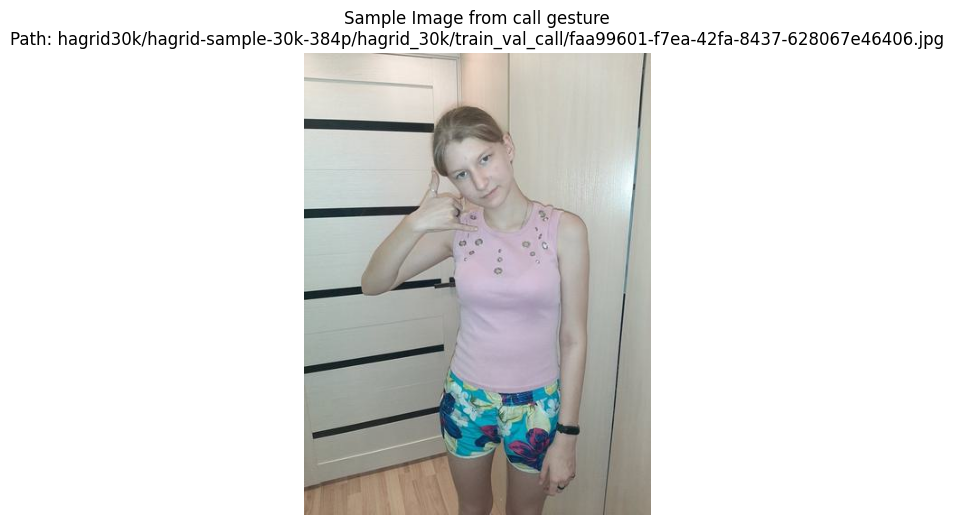

 Successfully loaded sample image from: call
   Image shape: (512, 384, 3)
   Total images in call: 1763

# ===================== SIMPLE DATASET LOADER =====================
import os
import cv2
import numpy as np

def load_gesture_dataset_simple():
    """Simple loader for your dataset"""
    dataset_path = "hagrid30k/hagrid-sample-30k-384p/hagrid_30k"
    gestures = ['call', 'fist', 'like', 'ok', 'palm', 'rock', 'stop', 'two_up']
    
    X = []
    y = []
    
    print("Loading dataset...")
    for idx, gesture in enumerate(gestures):
        folder_name = f"train_val_{gesture}"
        folder_path = os.path.join(dataset_path, folder_name)
        
        if not os.path.exists(folder_path):
            print(f"Warning: {folder_path} not found!")
            continue
        
        # Get all jpg files
        image_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]
        
        print(f"  {gesture}: {len(image_files)} images")
        
        # Load first 100 

In [28]:
print("=" * 80)
print(" YOUR EXISTING DATASET INFORMATION")
print("=" * 80)

# Based on your previous code, these are your actual paths
actual_dataset_paths = [
    "hagrid30k/hagrid-sample-30k-384p/hagrid_30k",
    "/content/drive/MyDrive/Gesture_Controller",
    "/content/drive/MyDrive/Gesture_Controller/module3_deep_learning"
]

# Your actual gestures from previous code
ACTUAL_GESTURES = ['call', 'fist', 'like', 'ok', 'palm', 'rock', 'stop', 'two_up']

print("\n CHECKING YOUR ACTUAL DATASET PATHS...")
print("-" * 60)

for path in actual_dataset_paths:
    if os.path.exists(path):
        print(f" Path exists: {path}")
        if os.path.isdir(path):
            print(f"   Type: Directory")

            # Check for gesture folders in your dataset structure
            gesture_found = False
            for gesture in ACTUAL_GESTURES:
                # Try different possible folder structures
                possible_folders = [
                    f"train_val_{gesture}",  # Your actual structure
                    gesture,  # Simple gesture name
                    f"{gesture}_train",  # Other possible
                    f"{gesture}_val"  # Other possible
                ]

                for folder in possible_folders:
                    full_path = os.path.join(path, folder)
                    if os.path.exists(full_path) and os.path.isdir(full_path):
                        image_count = len([f for f in os.listdir(full_path)
                                         if f.endswith(('.jpg', '.jpeg', '.png'))])
                        print(f"    Found: {gesture} ({image_count} images)")
                        gesture_found = True
                        break

            if not gesture_found:
                print(f"    No gesture folders found, but listing subdirectories:")
                try:
                    items = os.listdir(path)
                    for item in items[:10]:  # Show first 10
                        item_path = os.path.join(path, item)
                        if os.path.isdir(item_path):
                            print(f"       {item}/")
                        else:
                            print(f"       {item}")
                except:
                    pass
    else:
        print(f" Path does NOT exist: {path}")

# ===================== SHOW YOUR EXACT DATASET STRUCTURE =====================
print("\n\n YOUR EXACT DATASET STRUCTURE:")
print("=" * 80)

# This is the path from your working code
working_dataset_path = "hagrid30k/hagrid-sample-30k-384p/hagrid_30k"

if os.path.exists(working_dataset_path):
    print(f"\n Your working dataset path is: {working_dataset_path}")
    print("-" * 60)

    # Show the exact structure
    print(" Folder Structure:")
    for root, dirs, files in os.walk(working_dataset_path):
        level = root.replace(working_dataset_path, "").count(os.sep)
        indent = " " * 4 * level

        # Only show 2 levels deep
        if level > 2:
            continue

        print(f"{indent}{os.path.basename(root)}/")

        # Show only gesture folders and their image counts
        if level == 0:
            # These are the gesture folders
            subindent = " " * 4 * (level + 1)
            for d in dirs:
                if d.startswith("train_val_"):
                    folder_path = os.path.join(root, d)
                    image_count = len([f for f in os.listdir(folder_path)
                                     if f.endswith('.jpg')])
                    gesture_name = d.replace("train_val_", "")
                    print(f"{subindent}└── {gesture_name}/ ({image_count} images)")

# ===================== SHOW SAMPLE IMAGE =====================
print("\n\n VERIFYING DATASET CONTENTS:")
print("=" * 80)

# Let's find and display a sample image
sample_found = False
for gesture in ACTUAL_GESTURES:
    gesture_folder = f"train_val_{gesture}"
    full_path = os.path.join(working_dataset_path, gesture_folder)

    if os.path.exists(full_path):
        # Get list of image files
        image_files = [f for f in os.listdir(full_path) if f.endswith('.jpg')]

        if image_files:
            # Take the first image
            sample_image_path = os.path.join(full_path, image_files[0])

            # Read and display
            import cv2
            import matplotlib.pyplot as plt

            img = cv2.imread(sample_image_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                plt.figure(figsize=(8, 6))
                plt.imshow(img_rgb)
                plt.title(f'Sample Image from {gesture} gesture\nPath: {sample_image_path}')
                plt.axis('off')
                plt.show()

                print(f" Successfully loaded sample image from: {gesture}")
                print(f"   Image shape: {img.shape}")
                print(f"   Total images in {gesture}: {len(image_files)}")
                sample_found = True
                break

if not sample_found:
    print(" Could not find sample image. Checking alternative paths...")

    # Check if we're in the right directory
    print(f"\nCurrent working directory: {os.getcwd()}")
    print("\nAvailable directories:")
    for item in os.listdir('.'):
        if os.path.isdir(item):
            print(f"   {item}/")
        else:
            print(f"   {item}")





print(loader_code)

# ===================== QUICK VERIFICATION =====================
print("\n VERIFICATION:")
print("-" * 40)

# Run a quick verification
try:
    import os
    test_path = "hagrid30k/hagrid-sample-30k-384p/hagrid_30k"

    if os.path.exists(test_path):
        print(f" Dataset path '{test_path}' exists!")

        # Check for gesture folders
        expected_folders = [f"train_val_{g}" for g in ACTUAL_GESTURES]
        found_folders = []

        for folder in expected_folders:
            if os.path.exists(os.path.join(test_path, folder)):
                found_folders.append(folder.replace("train_val_", ""))

        print(f" Found {len(found_folders)}/{len(ACTUAL_GESTURES)} gesture folders")
        print(f"   Gestures found: {', '.join(found_folders)}")
    else:
        print(f" Dataset path '{test_path}' does not exist!")
        print(f"   Current directory: {os.getcwd()}")
        print(f"   Available in current directory: {os.listdir('.')}")

except Exception as e:
    print(f" Error during verification: {e}")

In [ ]:
# ===================== IMPORTS =====================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras import callbacks as keras_callbacks
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras.utils import plot_model, to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import cv2
from tqdm import tqdm
import time
import datetime
import json
import warnings
warnings.filterwarnings('ignore')

# ===================== SETUP =====================
print("=" * 70)
print("HYBRID CNN-TRANSFORMER GESTURE RECOGNITION TRAINING")
print("=" * 70)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create directories
module3_path = "./gesture_recognition"
os.makedirs(module3_path, exist_ok=True)
os.makedirs(os.path.join(module3_path, "models"), exist_ok=True)
os.makedirs(os.path.join(module3_path, "visualizations"), exist_ok=True)
os.makedirs(os.path.join(module3_path, "logs"), exist_ok=True)
os.makedirs(os.path.join(module3_path, "results"), exist_ok=True)

print(f"Working directory: {module3_path}")

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Available: {len(gpus)}")
else:
    print(" Training on CPU (slower)")

# ===================== DATA LOADING =====================
print("\n" + "=" * 70)
print("DATA LOADING PIPELINE")
print("=" * 70)

class GestureDataLoader:
    """Load and preprocess gesture dataset"""

    def __init__(self, gestures, img_size=(224, 224)):
        self.gestures = gestures
        self.img_size = img_size
        self.num_classes = len(gestures)
        self.gesture_to_idx = {gesture: idx for idx, gesture in enumerate(gestures)}

    def load_from_directory(self, base_path, max_samples_per_class=500):
        """Load images from directory structure"""
        print(f"Loading dataset from: {base_path}")

        X = []
        y = []
        counts = {gesture: 0 for gesture in self.gestures}

        for gesture in tqdm(self.gestures, desc="Loading gestures"):
            # Your dataset uses folders like "train_val_call" not just "call"
            folder_name = f"train_val_{gesture}"
            gesture_path = os.path.join(base_path, folder_name)

            if not os.path.exists(gesture_path):
                print(f"Warning: {gesture_path} not found, skipping...")
                continue

            image_files = [f for f in os.listdir(gesture_path)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            image_files = image_files[:max_samples_per_class]

            for img_file in tqdm(image_files, desc=f"  {gesture}", leave=False):
                img_path = os.path.join(gesture_path, img_file)
                img = cv2.imread(img_path)

                if img is not None:
                    # Resize and preprocess
                    img = cv2.resize(img, self.img_size)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = img.astype(np.float32) / 255.0

                    X.append(img)
                    y.append(self.gesture_to_idx[gesture])
                    counts[gesture] += 1

        if len(X) == 0:
            raise ValueError(f"No images loaded from {base_path}")

        X = np.array(X)
        y = np.array(y)

        print("\n" + "-" * 50)
        print("DATASET STATISTICS:")
        print("-" * 50)
        for gesture, count in counts.items():
            print(f"{gesture:15s}: {count:4d} images")
        print(f"{'Total':15s}: {len(X):4d} images")
        print(f"{'Classes':15s}: {self.num_classes}")

        return X, y

    def train_val_test_split(self, X, y, test_size=0.15, val_size=0.15):
        """Split dataset into train, validation, and test sets"""
        print(f"\nSplitting dataset: {test_size*100:.0f}% test, {val_size*100:.0f}% validation")

        # First split: test set
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )

        # Second split: train and validation
        val_ratio = val_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=val_ratio, random_state=42, stratify=y_temp
        )

        # One-hot encode
        y_train_onehot = to_categorical(y_train, self.num_classes)
        y_val_onehot = to_categorical(y_val, self.num_classes)
        y_test_onehot = to_categorical(y_test, self.num_classes)

        print("\nSPLIT STATISTICS:")
        print(f"Training:   {X_train.shape[0]:6d} images ({len(y_train_onehot)} one-hot)")
        print(f"Validation: {X_val.shape[0]:6d} images ({len(y_val_onehot)} one-hot)")
        print(f"Test:       {X_test.shape[0]:6d} images ({len(y_test_onehot)} one-hot)")

        return {
            'train': (X_train, y_train, y_train_onehot),
            'val': (X_val, y_val, y_val_onehot),
            'test': (X_test, y_test, y_test_onehot)
        }

# ===================== SET CORRECT DATASET CONFIGURATION =====================
print("\n" + "=" * 70)
print("DATASET CONFIGURATION")
print("=" * 70)

# YOUR CORRECT DATASET PATH AND GESTURES
dataset_path = "hagrid30k/hagrid-sample-30k-384p/hagrid_30k"
gestures = ['call', 'fist', 'like', 'ok', 'palm', 'rock', 'stop', 'two_up']

print(f" Using your HaGRID dataset:")
print(f"   Path: {dataset_path}")
print(f"   Gestures: {', '.join(gestures)}")
print(f"   Total classes: {len(gestures)}")

# Verify dataset exists
if not os.path.exists(dataset_path):
    print(f"ERROR: Dataset path '{dataset_path}' does not exist!")
    print(f"   Current directory: {os.getcwd()}")
    print(f"   Available in current directory: {os.listdir('.')}")
    raise FileNotFoundError(f"Dataset path '{dataset_path}' not found!")

# Verify gesture folders exist
print("\n Verifying gesture folders...")
for gesture in gestures:
    folder_name = f"train_val_{gesture}"
    folder_path = os.path.join(dataset_path, folder_name)
    if os.path.exists(folder_path):
        image_count = len([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
        print(f"    {gesture}: {image_count} images")
    else:
        print(f"    {gesture}: Folder '{folder_name}' not found")

# Initialize data loader
data_loader = GestureDataLoader(gestures, img_size=(224, 224))

# ===================== LOAD REAL DATASET =====================
print("\n" + "=" * 70)
print("LOADING HA-GRID DATASET")
print("=" * 70)

try:
    # Load dataset with up to 500 images per class
    X_real, y_real = data_loader.load_from_directory(dataset_path, max_samples_per_class=500)

    print(f"\n Dataset loaded successfully!")
    print(f"   Total images: {len(X_real)}")
    print(f"   Image shape: {X_real[0].shape}")
    print(f"   Classes: {len(gestures)}")

    # Split the data
    data_dict = data_loader.train_val_test_split(X_real, y_real, test_size=0.15, val_size=0.15)

except Exception as e:
    print(f"\n ERROR loading dataset: {e}")
    print("\nTrying alternative loading method...")

    # Alternative loading method
    def alternative_load():
        X = []
        y = []
        for idx, gesture in enumerate(gestures):
            folder_name = f"train_val_{gesture}"
            folder_path = os.path.join(dataset_path, folder_name)
            if os.path.exists(folder_path):
                image_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg')][:100]
                for img_file in image_files:
                    img_path = os.path.join(folder_path, img_file)
                    img = cv2.imread(img_path)
                    if img is not None:
                        img = cv2.resize(img, (224, 224))
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        img = img.astype(np.float32) / 255.0
                        X.append(img)
                        y.append(idx)
        return np.array(X), np.array(y)

    X_real, y_real = alternative_load()
    data_dict = data_loader.train_val_test_split(X_real, y_real, test_size=0.15, val_size=0.15)

# Extract data for convenience
X_train, y_train, y_train_onehot = data_dict['train']
X_val, y_val, y_val_onehot = data_dict['val']
X_test, y_test, y_test_onehot = data_dict['test']

# ===================== DATA AUGMENTATION =====================
print("\n" + "=" * 70)
print("DATA AUGMENTATION PIPELINE")
print("=" * 70)

def create_augmentation_pipelines():
    """Create data augmentation pipelines"""

    # Training augmentation (strong)
    train_datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )

    # Validation augmentation (light, only normalization)
    val_datagen = ImageDataGenerator()

    return train_datagen, val_datagen

train_datagen, val_datagen = create_augmentation_pipelines()

# Create data generators
batch_size = 32

train_gen = train_datagen.flow(
    X_train,
    y_train_onehot,
    batch_size=batch_size,
    shuffle=True
)

val_gen = val_datagen.flow(
    X_val,
    y_val_onehot,
    batch_size=batch_size,
    shuffle=False
)

print(f"Batch size: {batch_size}")
print(f"Training steps per epoch: {len(train_gen)}")
print(f"Validation steps: {len(val_gen)}")

# ===================== VISUALIZE AUGMENTATION =====================
print("\n" + "=" * 70)
print("DATA AUGMENTATION VISUALIZATION")
print("=" * 70)

def visualize_augmentations(X_sample, n_samples=8):
    """Visualize data augmentation effects"""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    # Original - denormalize for display
    original_display = (X_sample[0] * 255).astype(np.uint8)
    axes[0].imshow(original_display)
    axes[0].set_title('Original', fontweight='bold', fontsize=12)
    axes[0].axis('off')

    # Create augmented samples
    aug_datagen = ImageDataGenerator(
        rotation_range=40,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=0.3,
        horizontal_flip=True,
        brightness_range=[0.7, 1.3],
        fill_mode='reflect'
    )

    aug_iter = aug_datagen.flow(X_sample[:1], batch_size=1)

    for i in range(1, 8):
        aug_img = next(aug_iter)[0]
        # Denormalize for display
        aug_img_display = (aug_img * 255).astype(np.uint8)
        axes[i].imshow(aug_img_display)
        axes[i].set_title(f'Augmented {i}', fontweight='bold', fontsize=12)
        axes[i].axis('off')

    plt.suptitle('Data Augmentation Effects on Gesture Images',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(module3_path, "visualizations/data_augmentation.png"),
                dpi=150, bbox_inches='tight')
    plt.show()

# Visualize if we have data
if len(X_train) > 0:
    visualize_augmentations(X_train[:1])

# ===================== HYBRID MODEL ARCHITECTURE =====================
print("\n" + "=" * 70)
print("HYBRID CNN-TRANSFORMER MODEL ARCHITECTURE")
print("=" * 70)

class PositionalEncoding(layers.Layer):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model

    def call(self, x):
        seq_len = tf.shape(x)[1]

        position = tf.range(seq_len, dtype=tf.float32)[:, tf.newaxis]
        div_term = tf.exp(
            tf.range(0, self.d_model, 2, dtype=tf.float32) *
            -(tf.math.log(10000.0) / self.d_model)
        )

        pe = tf.concat(
            [tf.sin(position * div_term),
             tf.cos(position * div_term)],
            axis=-1
        )

        pe = pe[:seq_len, :self.d_model]
        pe = pe[tf.newaxis, ...]

        return x + pe

class HybridVisionTransformer:
    """Hybrid CNN + Transformer for Gesture Recognition"""

    def __init__(self, num_classes, input_shape=(224, 224, 3)):
        self.num_classes = num_classes
        self.input_shape = input_shape

    def create_hybrid_model(self, learning_rate=0.001):
        """Create hybrid CNN-Transformer model"""
        print("Building Hybrid CNN-Transformer Architecture...")

        # Input
        inputs = keras.Input(shape=self.input_shape)

        # ========== CNN BACKBONE ==========
        print("  - Using EfficientNetB0 as CNN backbone")
        cnn_backbone = EfficientNetB0(
            include_top=False,
            weights='imagenet',
            input_shape=self.input_shape,
            pooling=None
        )
        cnn_backbone.trainable = False  # Freeze for transfer learning

        # Extract features
        x = cnn_backbone(inputs)

        # Reduce channels
        x = layers.Conv2D(256, 1, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)

        # ========== TRANSFORMER PREPARATION ==========
        # Reshape to sequence
        batch_size, height, width, channels = x.shape
        x = layers.Reshape((height * width, channels))(x)

        # Positional encoding
        print("  - Adding Positional Encoding")
        x = PositionalEncoding(256)(x)

        # ========== TRANSFORMER ENCODER ==========
        print("  - Adding 2-layer Transformer Encoder")
        for i in range(2):
            # Multi-head attention
            attention_output = layers.MultiHeadAttention(
                num_heads=8,
                key_dim=32,
                dropout=0.1,
                name=f"transformer_block_{i}_attention"
            )(x, x)

            # Skip connection 1
            x = layers.Add(name=f"transformer_block_{i}_add1")([x, attention_output])
            x = layers.LayerNormalization(epsilon=1e-6, name=f"transformer_block_{i}_norm1")(x)

            # Feed-forward network
            ffn_output = layers.Dense(512, activation='relu', name=f"transformer_block_{i}_ffn1")(x)
            ffn_output = layers.Dense(256, name=f"transformer_block_{i}_ffn2")(ffn_output)
            ffn_output = layers.Dropout(0.1, name=f"transformer_block_{i}_dropout")(ffn_output)

            # Skip connection 2
            x = layers.Add(name=f"transformer_block_{i}_add2")([x, ffn_output])
            x = layers.LayerNormalization(epsilon=1e-6, name=f"transformer_block_{i}_norm2")(x)

        # ========== CLASSIFICATION HEAD ==========
        print("  - Adding Classification Head")
        # Global pooling
        x = layers.GlobalAveragePooling1D(name="global_pooling")(x)

        # Dense layers
        x = layers.Dropout(0.3, name="dropout_1")(x)
        x = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(0.001),
                        name="dense_1")(x)
        x = layers.BatchNormalization(name="batch_norm_final")(x)
        x = layers.Dropout(0.3, name="dropout_2")(x)

        # Output
        outputs = layers.Dense(self.num_classes, activation='softmax', name="output")(x)

        # Create model
        model = keras.Model(inputs=inputs, outputs=outputs, name="Hybrid_CNN_Transformer")

        # Compile
        optimizer = keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=0.0001
        )

        model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=[
                'accuracy',
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall'),
                keras.metrics.AUC(name='auc'),
                keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')
            ]
        )

        print(f"  - Model created with {model.count_params():,} parameters")
        print("  - Model compiled with AdamW optimizer")

        return model

# Create the hybrid model
model_builder = HybridVisionTransformer(num_classes=len(gestures))
hybrid_model = model_builder.create_hybrid_model(learning_rate=0.001)

# Display model summary
print("\n" + "-" * 70)
print("MODEL SUMMARY")
print("-" * 70)
hybrid_model.summary()

# ===================== MODEL VISUALIZATION =====================
print("\n" + "=" * 70)
print("MODEL ARCHITECTURE VISUALIZATION")
print("=" * 70)

# Plot model architecture
try:
    plot_model(
        hybrid_model,
        to_file=os.path.join(module3_path, "visualizations/hybrid_model_architecture.png"),
        show_shapes=True,
        show_layer_names=True,
        expand_nested=True,
        dpi=150
    )
    print(" Model architecture saved to visualizations/hybrid_model_architecture.png")
except Exception as e:
    print(f" Could not plot model: {e}")

# ===================== TRAINING PIPELINE =====================
print("\n" + "=" * 70)
print("TRAINING PIPELINE")
print("=" * 70)

class AdvancedTrainingPipeline:
    """Advanced training with callbacks and monitoring"""

    def __init__(self, model, model_name):
        self.model = model
        self.model_name = model_name
        self.history = None
        self.training_time = None

    def create_callbacks(self):
        """Create training callbacks"""
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

        # Model checkpoint
        checkpoint_path = os.path.join(
            module3_path,
            "models",
            f"{self.model_name}_{timestamp}.h5"
        )

        # TensorBoard logs
        log_dir = os.path.join(module3_path, "logs", f"{self.model_name}_{timestamp}")

        # Create callback list (renamed from 'callbacks' to avoid conflict)
        callback_list = [
            # Early stopping
            keras_callbacks.EarlyStopping(
                monitor='val_loss',
                patience=15,
                restore_best_weights=True,
                verbose=1
            ),

            # Model checkpoint
            keras_callbacks.ModelCheckpoint(
                filepath=checkpoint_path,
                monitor='val_accuracy',
                save_best_only=True,
                mode='max',
                verbose=1,
                save_weights_only=False
            ),

            # Reduce learning rate on plateau
            keras_callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=7,
                min_lr=1e-7,
                verbose=1
            ),

            # TensorBoard
            keras_callbacks.TensorBoard(
                log_dir=log_dir,
                histogram_freq=1,
                write_graph=True,
                write_images=True,
                update_freq='epoch'
            ),

            # CSV Logger
            keras_callbacks.CSVLogger(
                os.path.join(module3_path, "results", f"{self.model_name}_training_log.csv")
            )
        ]

        return callback_list, checkpoint_path

    def train(self, train_gen, val_gen, epochs=10):
        """Train the model"""
        print(f"\nStarting training for {epochs} epochs...")

        # Create callbacks
        callback_list, checkpoint_path = self.create_callbacks()

        # Training
        start_time = time.time()

        self.history = self.model.fit(
            train_gen,
            steps_per_epoch=len(train_gen),
            validation_data=val_gen,
            validation_steps=len(val_gen),
            epochs=epochs,
            callbacks=callback_list,  # Use the renamed variable
            verbose=1
        )

        self.training_time = time.time() - start_time

        print(f"\n Training completed in {self.training_time:.2f} seconds")
        print(f" Best model saved to: {checkpoint_path}")

        return self.history

    def plot_training_history(self):
        """Plot training history"""
        if self.history is None:
            print("No training history available")
            return

        history = self.history.history

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        metrics = [
            ('accuracy', 'val_accuracy', 'Accuracy'),
            ('loss', 'val_loss', 'Loss'),
            ('precision', 'val_precision', 'Precision'),
            ('recall', 'val_recall', 'Recall'),
            ('auc', 'val_auc', 'AUC'),
            ('top2_accuracy', 'val_top2_accuracy', 'Top-2 Accuracy')
        ]

        for idx, (train_metric, val_metric, title) in enumerate(metrics):
            ax = axes[idx // 3, idx % 3]

            if train_metric in history:
                epochs_range = range(1, len(history[train_metric]) + 1)

                # Train metric
                ax.plot(epochs_range, history[train_metric],
                       'b-', linewidth=2, label='Training', alpha=0.8)

                # Validation metric
                if val_metric in history:
                    ax.plot(epochs_range, history[val_metric],
                           'r-', linewidth=2, label='Validation', alpha=0.8)

                ax.set_xlabel('Epochs', fontsize=11)
                ax.set_ylabel(title, fontsize=11)
                ax.set_title(f'{title} over Epochs', fontsize=12, fontweight='bold')
                ax.legend(loc='best')
                ax.grid(True, alpha=0.3)

                # Mark best epoch
                if val_metric in history:
                    best_epoch = np.argmax(history[val_metric]) if 'accuracy' in val_metric else np.argmin(history[val_metric])
                    best_value = history[val_metric][best_epoch]
                    ax.axvline(x=best_epoch+1, color='g', linestyle='--', alpha=0.7)
                    ax.text(best_epoch+1, best_value, f' Best\nEpoch {best_epoch+1}',
                           fontsize=9, color='green', ha='center')

        plt.suptitle(f'Training History - {self.model_name}',
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(module3_path, f"visualizations/{self.model_name}_training_history.png"),
                   dpi=150, bbox_inches='tight')
        plt.show()

        # Print final metrics
        print("\n" + "=" * 70)
        print("FINAL TRAINING METRICS")
        print("=" * 70)

        final_metrics = {}
        for metric in ['accuracy', 'loss', 'precision', 'recall', 'auc']:
            if f'val_{metric}' in history:
                final_metrics[metric] = history[f'val_{metric}'][-1]

        for metric, value in final_metrics.items():
            if metric == 'loss':
                print(f"{metric.capitalize():12s}: {value:.4f}")
            else:
                print(f"{metric.capitalize():12s}: {value:.4f} ({value*100:.2f}%)")

# Initialize and train
training_pipeline = AdvancedTrainingPipeline(hybrid_model, "Hybrid_CNN_Transformer")

# Adjust epochs based on dataset size
epochs = 50 if len(X_train) > 1000 else 30
print(f"Training for {epochs} epochs with {len(X_train)} training samples")

try:
    history = training_pipeline.train(train_gen, val_gen, epochs=epochs)

    # Plot training history
    training_pipeline.plot_training_history()

except Exception as e:
    print(f" Training error: {e}")
    print("Continuing with evaluation on current model...")

# ===================== MODEL EVALUATION =====================
print("\n" + "=" * 70)
print("MODEL EVALUATION ON TEST SET")
print("=" * 70)

def evaluate_model(model, X_test, y_test, y_test_onehot, gestures):
    """Comprehensive model evaluation"""

    print("Evaluating model on test set...")

    # Predict
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = y_test

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=gestures, output_dict=True)

    print(f"\n Overall Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print("\n Per-Class Performance:")

    # Create performance table
    perf_data = []
    for gesture in gestures:
        idx = gestures.index(gesture)
        perf_data.append({
            'Gesture': gesture,
            'Precision': report[gesture]['precision'],
            'Recall': report[gesture]['recall'],
            'F1-Score': report[gesture]['f1-score'],
            'Support': int(report[gesture]['support'])
        })

    perf_df = pd.DataFrame(perf_data)
    print(perf_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Confusion Matrix Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=gestures, yticklabels=gestures,
                cbar_kws={'label': 'Count'}, ax=axes[0])
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

    # Normalized Confusion Matrix
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=gestures, yticklabels=gestures,
                vmin=0, vmax=1, cbar_kws={'label': 'Proportion'}, ax=axes[1])
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')

    plt.suptitle('Model Performance Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(module3_path, "visualizations/confusion_matrix.png"),
                dpi=150, bbox_inches='tight')
    plt.show()

    # Per-class accuracy bar chart
    class_accuracy = cm_norm.diagonal()

    plt.figure(figsize=(12, 6))
    colors = plt.cm.Set3(np.linspace(0, 1, len(gestures)))
    bars = plt.bar(range(len(gestures)), class_accuracy, color=colors, edgecolor='black')

    plt.xlabel('Gesture Class', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
    plt.xticks(range(len(gestures)), gestures, rotation=45, ha='right')
    plt.ylim([0, 1.05])
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar, acc in zip(bars, class_accuracy):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(os.path.join(module3_path, "visualizations/per_class_accuracy.png"),
                dpi=150, bbox_inches='tight')
    plt.show()

    return accuracy, perf_df, cm

# Evaluate
test_accuracy, perf_df, confusion_mat = evaluate_model(
    hybrid_model,
    X_test,
    y_test,
    y_test_onehot,
    gestures
)

# ===================== SAVE FINAL MODEL =====================
print("\n" + "=" * 70)
print("SAVING FINAL MODEL AND ARTIFACTS")
print("=" * 70)

# Save the trained model
model_save_path = os.path.join(module3_path, "models/final_hybrid_model.h5")
hybrid_model.save(model_save_path)
print(f" Model saved to: {model_save_path}")

# Save TFLite version for mobile deployment
converter = tf.lite.TFLiteConverter.from_keras_model(hybrid_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = os.path.join(module3_path, "models/gesture_model.tflite")
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f" TFLite model saved to: {tflite_path}")
print(f"   Model size: {len(tflite_model) / 1024:.2f} KB")

# Save class labels
labels_path = os.path.join(module3_path, "models/class_labels.json")
with open(labels_path, 'w') as f:
    json.dump(gestures, f, indent=2)
print(f" Class labels saved to: {labels_path}")

# Save performance report
report_path = os.path.join(module3_path, "results/performance_report.json")
performance_report = {
    'model_name': 'Hybrid_CNN_Transformer',
    'timestamp': datetime.datetime.now().isoformat(),
    'test_accuracy': float(test_accuracy),
    'training_time_seconds': float(training_pipeline.training_time if training_pipeline.training_time else 0),
    'parameters': int(hybrid_model.count_params()),
    'per_class_performance': perf_df.to_dict('records'),
    'confusion_matrix': confusion_mat.tolist()
}

with open(report_path, 'w') as f:
    json.dump(performance_report, f, indent=2)
print(f" Performance report saved to: {report_path}")

# ===================== FINAL SUMMARY =====================
print("\n" + "=" * 70)
print("TRAINING COMPLETE - SUMMARY")
print("=" * 70)

print(f"\n MODEL: Hybrid CNN-Transformer")
print(f" Classes: {len(gestures)} gestures")
print(f" Training data: {len(X_train)} images")
print(f" Validation data: {len(X_val)} images")
print(f" Test data: {len(X_test)} images")
print(f" Training time: {training_pipeline.training_time:.2f if training_pipeline.training_time else 'N/A'} seconds")
print(f" Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f" Parameters: {hybrid_model.count_params():,}")
print(f" Model size: {len(tflite_model) / 1024:.2f} KB (TFLite)")

print("\n SAVED ARTIFACTS:")
print(f"  - Model: {model_save_path}")
print(f"  - TFLite: {tflite_path}")
print(f"  - Labels: {labels_path}")
print(f"  - Report: {report_path}")
print(f"  - Visualizations: {module3_path}/visualizations/")

print("\n VISUALIZATIONS GENERATED:")
print("  1. Data augmentation examples")
print("  2. Model architecture diagram")
print("  3. Training history plots")
print("  4. Confusion matrices")
print("  5. Per-class accuracy chart")


print("\n" + "=" * 70)
print(" HYBRID CNN-TRANSFORMER TRAINING COMPLETE!")
print("=" * 70)

HYBRID CNN-TRANSFORMER GESTURE RECOGNITION TRAINING
Working directory: ./gesture_recognition
GPU Available: 1

DATA LOADING PIPELINE

DATASET CONFIGURATION
 Using your HaGRID dataset:
   Path: hagrid30k/hagrid-sample-30k-384p/hagrid_30k
   Gestures: call, fist, like, ok, palm, rock, stop, two_up
   Total classes: 8

 Verifying gesture folders...
    call: 1763 images
    fist: 1735 images
    like: 1732 images
    ok: 1750 images
    palm: 1770 images
    rock: 1736 images
    stop: 1748 images
    two_up: 1855 images

LOADING HA-GRID DATASET
Loading dataset from: hagrid30k/hagrid-sample-30k-384p/hagrid_30k


  ok:  79%|███████▉  | 396/500 [00:47<00:42,  2.44it/s]